# Домашнее задание. Нейросетевая классификация текстов

В этом домашнем задании вам предстоит самостоятельно решить задачу классификации текстов на основе семинарского кода. Мы будем использовать датасет [ag_news](https://paperswithcode.com/dataset/ag-news). Это датасет для классификации новостей на 4 темы: "World", "Sports", "Business", "Sci/Tech".

Установим модуль datasets, чтобы нам проще было работать с данными.

In [ ]:
!pip install datasets

Импорт необходимых библиотек

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import datasets

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List
import string

import seaborn
seaborn.set(palette='summer')

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Подготовка данных
Для вашего удобства, мы привели код обработки датасета в ноутбуке. Ваша задача --- обучить модель, которая получит максимальное возможное качество на тестовой части.

In [ ]:
# Загрузим датасет
dataset = datasets.load_dataset('ag_news')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Как и в семинаре, выполним следующие шаги:
* Составим словарь
* Создадим класс WordDataset
* Выделим обучающую и тестовую часть, создадим DataLoader-ы.

In [ ]:
words = Counter()

for example in tqdm(dataset['train']['text']):
    # Приводим к нижнему регистру и убираем пунктуацию
    prccessed_text = example.lower().translate(
        str.maketrans('', '', string.punctuation))

    for word in word_tokenize(prccessed_text):
        words[word] += 1


vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
counter_threshold = 25

for char, cnt in words.items():
    if cnt > counter_threshold:
        vocab.add(char)

print(f'Размер словаря: {len(vocab)}')

word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

  0%|          | 0/120000 [00:00<?, ?it/s]

Размер словаря: 11842


In [ ]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        processed_text = self.data[idx]['text'].lower().translate(
            str.maketrans('', '', string.punctuation))
        tokenized_sentence = [self.bos_id]
        tokenized_sentence += [
            word2ind.get(word, self.unk_id) for word in word_tokenize(processed_text)
            ]
        tokenized_sentence += [self.eos_id]

        train_sample = {
            "text": tokenized_sentence,
            "label": self.data[idx]['label']
        }

        return train_sample

    def __len__(self) -> int:
        return len(self.data)


def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>'], max_len=256) -> torch.Tensor:
    seq_lens = [len(x['text']) for x in input_batch]
    max_seq_len = min(max(seq_lens), max_len)

    new_batch = []
    for sequence in input_batch:
        sequence['text'] = sequence['text'][:max_seq_len]
        for _ in range(max_seq_len - len(sequence['text'])):
            sequence['text'].append(pad_id)

        new_batch.append(sequence['text'])

    sequences = torch.LongTensor(new_batch).to(device)
    labels = torch.LongTensor([x['label'] for x in input_batch]).to(device)

    new_batch = {
        'input_ids': sequences,
        'label': labels
    }

    return new_batch

In [ ]:
train_dataset = WordDataset(dataset['train'])

np.random.seed(42)
idx = np.random.choice(np.arange(len(dataset['test'])), 5000)
eval_dataset = WordDataset(dataset['test'].select(idx))

batch_size = 32
train_dataloader = DataLoader(
    train_dataset, shuffle=True, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, shuffle=False, collate_fn=collate_fn_with_padding, batch_size=batch_size)

## Постановка задачи
Ваша задача -- получить максимальное возможное accuracy на `eval_dataloader`. Ниже приведена функция, которую вам необходимо запустить для обученной модели, чтобы вычислить качество её работы.

In [ ]:
def evaluate(model, eval_dataloader) -> float:
    """
    Calculate accuracy on validation dataloader.
    """

    predictions = []
    target = []
    with torch.no_grad():
        for batch in eval_dataloader:
            logits = model(batch['input_ids'])
            predictions.append(logits.argmax(dim=1))
            target.append(batch['label'])

    predictions = torch.cat(predictions)
    target = torch.cat(target)
    accuracy = (predictions == target).float().mean().item()

    return accuracy

## Ход работы
Оценка за домашнее задание складывается из четырех частей:
### Запуск базовой модели с семинара на новом датасете (1 балл)
На семинаре мы создали модель, которая дает на нашей задаче довольно высокое качество. Ваша цель --- обучить ее и вычислить `score`, который затем можно будет использовать в качестве бейзлайна.

В модели появится одно важное изменение: количество классов теперь равно не 2, а 4. Обратите на это внимание и найдите, что в коде создания модели нужно модифицировать, чтобы учесть это различие.

### Проведение экспериментов по улучшению модели (2 балла за каждый эксперимент)
Чтобы улучшить качество базовой модели, можно попробовать различные идеи экспериментов. Каждый выполненный эксперимент будет оцениваться в 2 балла. Для получения полного балла за этот пункт вам необходимо выполнить по крайней мере 2 эксперимента. Не расстраивайтесь, если какой-то эксперимент не дал вам прироста к качеству: он все равно зачтется, если выполнен корректно.

Вот несколько идей экспериментов:
* **Модель RNN**. Попробуйте другие нейросетевые модели --- LSTM и GRU. Мы советуем обратить внимание на [GRU](https://pytorch.org/docs/stable/generated/torch.nn.GRU.html), так как интерфейс этого класса ничем не отличается от обычной Vanilla RNN, которую мы использовали на семинаре.
* **Увеличение количества рекуррентных слоев модели**. Это можно сделать с помощью параметра `num_layers` в классе `nn.RNN`. В такой модели выходы первой RNN передаются в качестве входов второй RNN и так далее.
* **Изменение архитектуры после применения RNN**. В базовой модели используется агрегация со всех эмбеддингов. Возможно, вы захотите конкатенировать результат агрегации и эмбеддинг с последнего токена.
* **Подбор гиперпараметров и обучение до сходимости**. Возможно, для получения более высокого качества просто необходимо увеличить количество эпох обучения нейросети, а также попробовать различные гиперпараметры: размер словаря, `dropout_rate`, `hidden_dim`.

Обратите внимание, что главное правило проведения экспериментов --- необходимо совершать одно архитектурное изменение в одном эксперименте. Если вы совершите несколько изменений, то будет неясно, какое именно из изменений дало прирост к качеству.

### Получение высокого качества (3 балла)
В конце вашей работы вы должны указать, какая из моделей дала лучший результат, и вывести качество, которое дает лучшая модель, с помощью функции `evaluate`. Ваша модель будет оцениваться по метрике `accuracy` следующим образом:
* $accuracy < 0.9$ --- 0 баллов;
* $0.9 \leqslant accuracy < 0.91$ --- 1 балл;
* $0.91 \leqslant accuracy < 0.915$ --- 2 балла;
* $0.915 \leqslant accuracy$ --- 3 балла.

### Оформление отчета (2 балла)
В конце работы подробно опишите все проведенные эксперименты.
* Укажите, какие из экспериментов принесли улучшение, а какие --- нет.
* Проанализируйте графики сходимости моделей в проведенных экспериментах. Являются ли колебания качества обученных моделей существенными в зависимости от эпохи обучения, или же сходимость стабильная?
* Укажите, какая модель получилась оптимальной.

Желаем удачи!

# Запуск базовой модели с семинара на новом датасете

Теперь у нас 4 класса, учтем это:

In [ ]:
class CharLM(nn.Module):
    def __init__(
        self, hidden_dim: int, vocab_size: int, num_classes: int = 4,
        aggregation_type: str = 'max'
        ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.RNN(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

        self.aggregation_type = aggregation_type

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]

        if self.aggregation_type == 'max':
            output = output.max(dim=1)[0] #[batch_size, hidden_dim]
        elif self.aggregation_type == 'mean':
            output = output.mean(dim=1) #[batch_size, hidden_dim]
        else:
            raise ValueError("Invalid aggregation_type")

        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, hidden_dim]
        prediction = self.projection(self.non_lin(output))  # [batch_size, num_classes]

        return prediction

Тут все в точности как на семинаре:

In [ ]:
model_basic = CharLM(hidden_dim=256, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model_basic.parameters())

Train тоже семинарский, но с сохранением чекпоинта при достижении accuracy 0.915 или выше

In [ ]:
import os
from copy import deepcopy

def train(
    model,
    num_epoch=5,
    eval_steps=None,
    threshold=0.915,
    save_dir="checkpoints",
):
    os.makedirs(save_dir, exist_ok=True)
    if eval_steps is None:
        eval_steps = max(1, len(train_dataloader) // 2)

    losses_type = {}
    acc_type = {}

    for aggregation_type in ['max', 'mean']:
        print(f"Starting training for {aggregation_type}")

        criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
        optimizer = torch.optim.Adam(model.parameters())

        epoch_losses, epoch_accs = [], []
        threshold_saved = False

        for epoch in range(num_epoch):
            model.train()
            batch_losses = []

            for i, batch in enumerate(tqdm(train_dataloader, desc=f'Training epoch {epoch}:')):
                optimizer.zero_grad()
                logits = model(batch['input_ids'])
                loss = criterion(logits, batch['label'])
                loss.backward()
                optimizer.step()
                batch_losses.append(loss.item())

                if (i + 1) % eval_steps == 0:
                    model.eval()
                    with torch.no_grad():
                        step_acc = evaluate(model, eval_dataloader)
                    model.train()

                    if (not threshold_saved) and (step_acc is not None) and (step_acc > threshold):
                        ckpt_path = os.path.join(
                            save_dir,
                            f"{aggregation_type}_epoch{epoch}_iter{i+1}_acc{step_acc:.4f}.pt"
                        )
                        torch.save(model.state_dict(), ckpt_path)
                        threshold_saved = True
                        print(f"[SAVE] {aggregation_type}: acc {step_acc:.4f} > {threshold}; saved to {ckpt_path}")

            mean_loss = float(sum(batch_losses) / max(1, len(batch_losses)))
            epoch_losses.append(mean_loss)

            model.eval()
            with torch.no_grad():
                epoch_acc = float(evaluate(model, eval_dataloader))
            epoch_accs.append(epoch_acc)

        torch.save({"losses": epoch_losses, "acc": epoch_accs},
                   os.path.join(save_dir, f"history_{aggregation_type}.pt"))

        losses_type[aggregation_type] = epoch_losses
        acc_type[aggregation_type] = epoch_accs

    return losses_type, acc_type


In [ ]:
losses_basic, acc_basic = train(model_basic, num_epoch=5)

Starting training for max


Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/3750 [00:00<?, ?it/s]

...

Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/3750 [00:00<?, ?it/s]

In [ ]:
def plot_losses_accs(losses_type, acc_type):
    plt.figure(figsize=(10, 5))

    for (name, values), color in zip(losses_type.items(), ['red', 'blue']):
        plt.plot(np.arange(len(losses_type[name])), losses_type[name], color=color, label=name)

    plt.title('Losses')
    plt.xlabel("epoch")
    plt.legend()
    plt.show()

    for (name, values), color in zip(losses_type.items(), ['red', 'blue']):
        plt.plot(np.arange(len(acc_type[name][1:])), acc_type[name][1:], color=color, label=name)
        print(f"Лучшая accuracy для подхода {name}: {(max(acc_type[name]) * 100):.2f}")

    plt.title('Accuracy')
    plt.xlabel("epoch")
    plt.legend()
    plt.show()

Взглянем на графики:

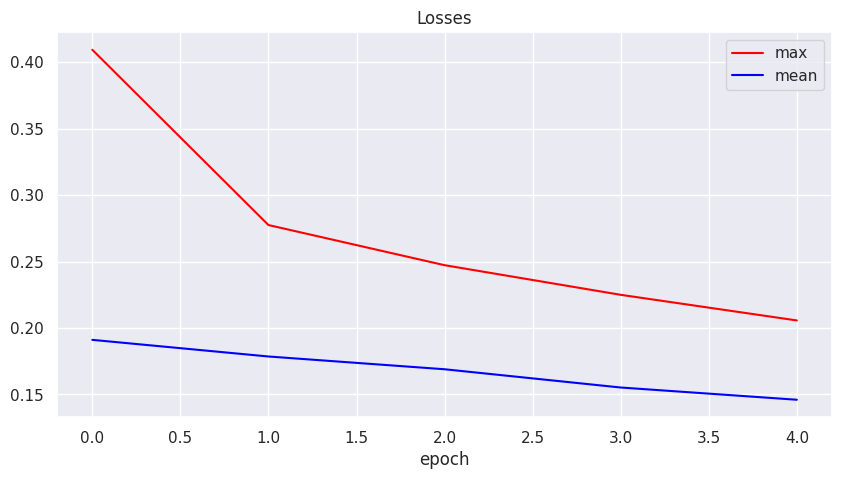

Лучшая accuracy для подхода max: 90.64
Лучшая accuracy для подхода mean: 90.40


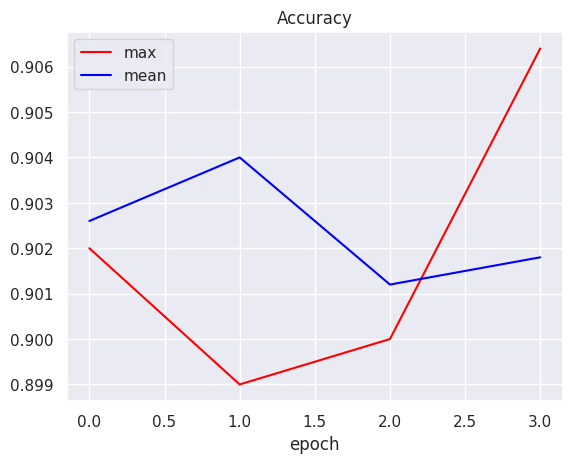

In [ ]:
plot_losses_accs(losses_basic, acc_basic)

Оба лосса убывают, а значит обучение еще идет, и mean даёт более устойчивое снижение лосса.

Графики accuracy не монотонны. Mean идёт относительно ровно, с небольшими колебаниями вокруг 0.903. Модель с усреднением признаков держит стабильный результат.

Max менее стабильна. Сначала падает (0.902-0.899), но потом резко растёт и выходит на 0.906, обгоняя mean. То есть max рискованнее, но может давать пиковую точность. Возможно, если дольше обучать, она либо стабилизируется, либо начнёт переобучаться.

#Проведение экспериментов по улучшению модели

Эта функция позволит сравнивать графики различных моделей при реализации одного архитектурного изменения в одном эксперименте.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_losses_accs_compare(
    losses_type1, acc_type1,
    losses_type2=None, acc_type2=None,
    losses_basic=None, acc_basic=None,
    basic_prefix="baseline",
    type1_prefix="type1",
    type2_prefix="type2"
):
    color_by_agg = {"max": "red", "mean": "blue"}
    aggs = ["max", "mean"]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.ravel()

    def _plot_one(ax, title, type1_vals, type2_vals, basic_vals, agg):
        color = color_by_agg.get(agg, None)

        if isinstance(type1_vals, (list, tuple, np.ndarray)):
            y = np.asarray(type1_vals, dtype=float)
            x = np.arange(len(y))
            ax.plot(x, y, label=f"{type1_prefix}", color=color, linestyle="--")

        if isinstance(type2_vals, (list, tuple, np.ndarray)):
            y = np.asarray(type2_vals, dtype=float)
            x = np.arange(len(y))
            ax.plot(x, y, label=f"{type2_prefix}", color=color, linestyle="-.")

        if isinstance(basic_vals, (list, tuple, np.ndarray)):
            yb = np.asarray(basic_vals, dtype=float)
            xb = np.arange(len(yb))
            ax.plot(xb, yb, label=f"{basic_prefix}", color=color, linestyle="-")

        ax.set_title(title)
        ax.set_xlabel("epoch")
        ax.grid(True, alpha=0.25)
        ax.legend()

    _plot_one(
        axes[0],
        "Loss (max)",
        losses_type1.get("max", []),
        (losses_type2 or {}).get("max", None),
        (losses_basic or {}).get("max", None),
        "max",
    )

    _plot_one(
        axes[1],
        "Loss (mean)",
        losses_type1.get("mean", []),
        (losses_type2 or {}).get("mean", None),
        (losses_basic or {}).get("mean", None),
        "mean",
    )

    _plot_one(
        axes[2],
        "Accuracy (max)",
        acc_type1.get("max", []),
        (acc_type2 or {}).get("max", None),
        (acc_basic or {}).get("max", None),
        "max",
    )
    if acc_type1.get("max"):
        print(f"Лучшая accuracy для {type1_prefix} max: {np.max(acc_type1['max'])*100:.2f}%")
    if acc_type2 and acc_type2.get("max"):
        print(f"Лучшая accuracy для {type2_prefix} max: {np.max(acc_type2['max'])*100:.2f}%")
    if acc_basic and acc_basic.get("max"):
        print(f"Лучшая accuracy для {basic_prefix} max: {np.max(acc_basic['max'])*100:.2f}%")

    _plot_one(
        axes[3],
        "Accuracy (mean)",
        acc_type1.get("mean", []),
        (acc_type2 or {}).get("mean", None),
        (acc_basic or {}).get("mean", None),
        "mean",
    )
    if acc_type1.get("mean"):
        print(f"Лучшая accuracy для {type1_prefix} mean: {np.max(acc_type1['mean'])*100:.2f}%")
    if acc_type2 and acc_type2.get("mean"):
        print(f"Лучшая accuracy для {type2_prefix} mean: {np.max(acc_type2['mean'])*100:.2f}%")
    if acc_basic and acc_basic.get("mean"):
        print(f"Лучшая accuracy для {basic_prefix} mean: {np.max(acc_basic['mean'])*100:.2f}%")

    axes[0].set_ylabel("loss")
    axes[2].set_ylabel("accuracy")

    plt.tight_layout()
    plt.show()


##Модель RNN

###GRU

In [ ]:
class GRULM(nn.Module):
    def __init__(
        self, hidden_dim: int, vocab_size: int, num_classes: int = 4,
        aggregation_type: str = 'max'
        ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

        self.aggregation_type = aggregation_type

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]

        if self.aggregation_type == 'max':
            output = output.max(dim=1)[0] #[batch_size, hidden_dim]
        elif self.aggregation_type == 'mean':
            output = output.mean(dim=1) #[batch_size, hidden_dim]
        else:
            raise ValueError("Invalid aggregation_type")

        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, hidden_dim]
        prediction = self.projection(self.non_lin(output))  # [batch_size, num_classes]

        return prediction

In [ ]:
model_gru = GRULM(hidden_dim=256, vocab_size=len(vocab)).to(device)

Starting training for max


Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

[SAVE] max: acc 0.9184 > 0.915; saved to checkpoints/max_epoch1_iter3750_acc0.9184.pt


Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

...

Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/3750 [00:00<?, ?it/s]

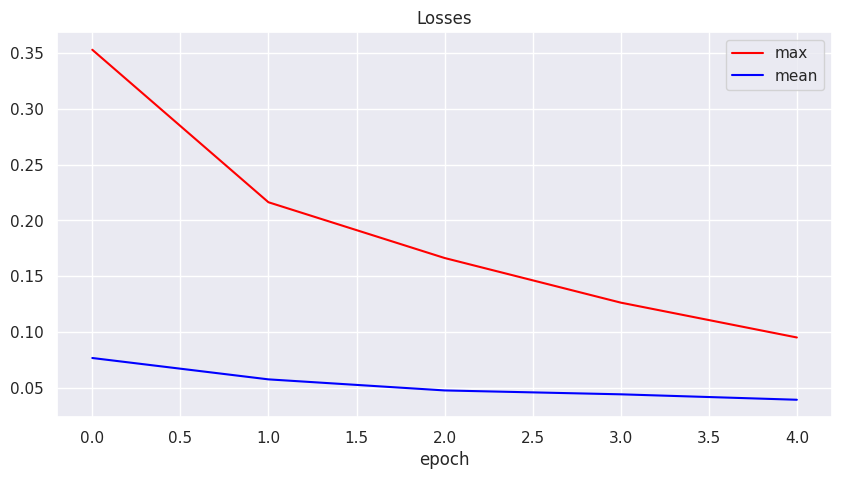

Лучшая accuracy для подхода max: 91.84
Лучшая accuracy для подхода mean: 91.02


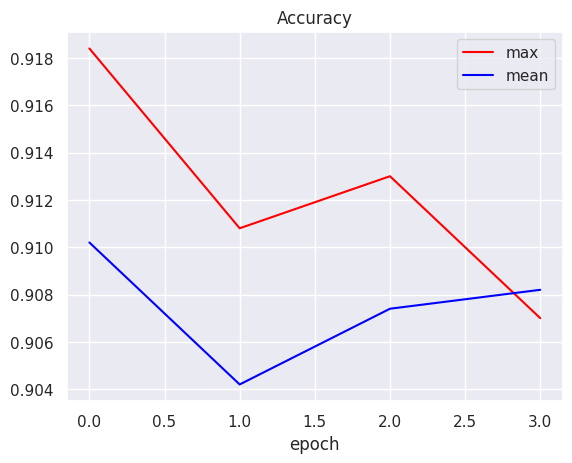

In [ ]:
losses_gru, acc_gru = train(model_gru, num_epoch=5)
plot_losses_accs(losses_gru, acc_gru)

Оба лосса убывают, но mean даёт более уверенное уменьшение лосса.

Обе accuracy показывают высокие результаты в начале обучения, но точность постепенно падает. С mean результат устойчивее, к концу обучения разрыв исчезает.

GRU в связке с mean показывает наиболее стабильное и плавное обучение.
GRU с max выглядит менее выгодным: быстрое начало, но хуже удержание результата.

###LSTM

In [ ]:
class LSTMLM(nn.Module):
    def __init__(
        self, hidden_dim: int, vocab_size: int, num_classes: int = 4,
        aggregation_type: str = 'max'
        ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

        self.aggregation_type = aggregation_type

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]

        if self.aggregation_type == 'max':
            output = output.max(dim=1)[0] #[batch_size, hidden_dim]
        elif self.aggregation_type == 'mean':
            output = output.mean(dim=1) #[batch_size, hidden_dim]
        else:
            raise ValueError("Invalid aggregation_type")

        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, hidden_dim]
        prediction = self.projection(self.non_lin(output))  # [batch_size, num_classes]

        return prediction

In [ ]:
model_lstm = LSTMLM(hidden_dim=256, vocab_size=len(vocab)).to(device)

Starting training for max


Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

[SAVE] max: acc 0.9152 > 0.915; saved to checkpoints/max_epoch1_iter3750_acc0.9152.pt


Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

...

Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/3750 [00:00<?, ?it/s]

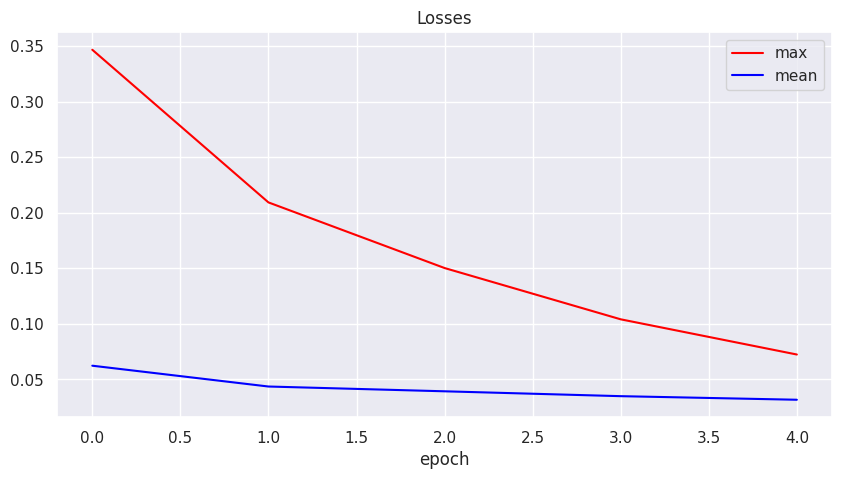

Лучшая accuracy для подхода max: 91.52
Лучшая accuracy для подхода mean: 90.88


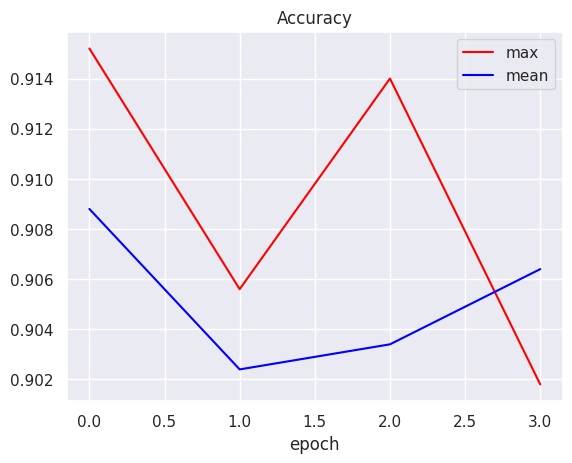

In [ ]:
losses_lstm, acc_lstm = train(model_lstm, num_epoch=5)
plot_losses_accs(losses_lstm, acc_lstm)

Аналогично предыдущим случаям, обе лосс-функции убывают, но mean сильнее.
И accuracy отлично стартуют, но после качество проседает, не хватает стабильности, особенно max.

###Сравним RNN, GRU и LSTM

Лучшая accuracy для GRU max: 91.84%
Лучшая accuracy для LSTM max: 91.52%
Лучшая accuracy для RNN max: 90.64%
Лучшая accuracy для GRU mean: 91.02%
Лучшая accuracy для LSTM mean: 90.88%
Лучшая accuracy для RNN mean: 90.40%


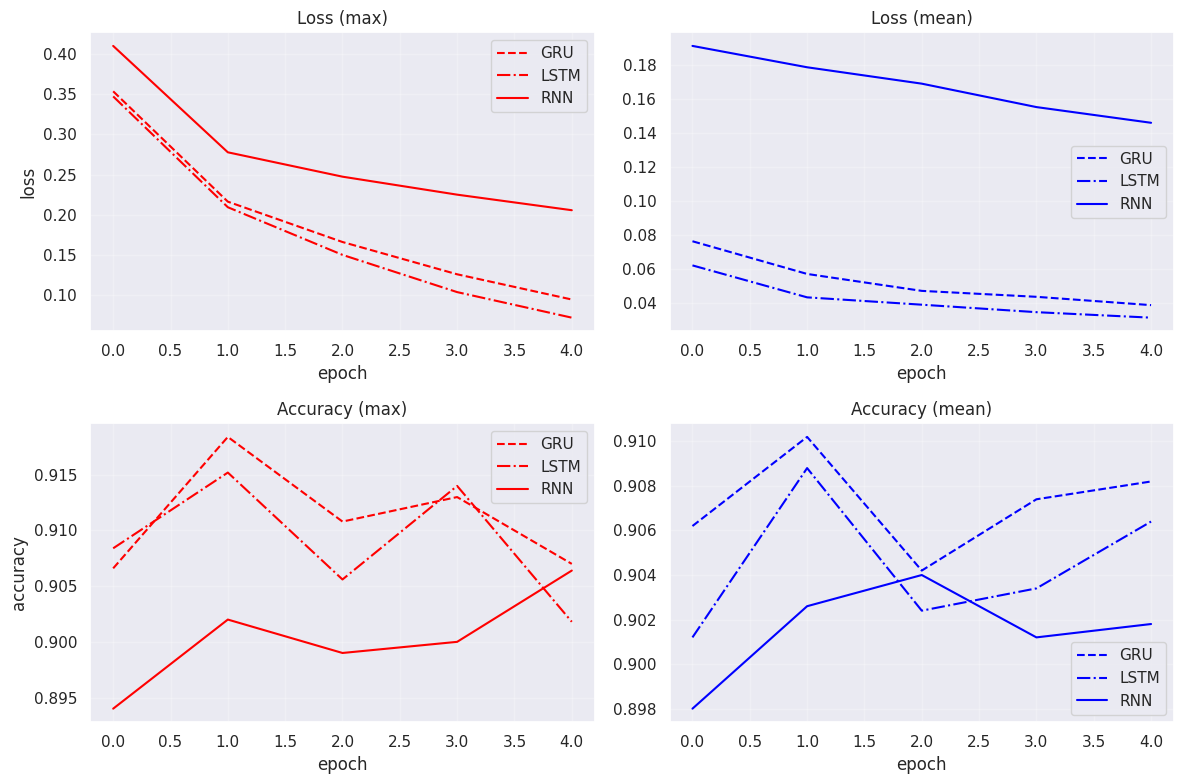

In [ ]:
plot_losses_accs_compare(
    losses_gru, acc_gru,
    losses_lstm, acc_lstm,
    losses_basic, acc_basic,
    basic_prefix="RNN",
    type1_prefix="GRU",
    type2_prefix="LSTM"
)

GRU и LSTM явно выигрывают у RNN по значениям loss и accuracy.

Наименьший лосс у LSTM в обоих случаях, а наибольшие показатели метрики у GRU. Но стабильность оставляет желать лучшего, колебания accuracy сильны.

RNN отстаёт: медленнее сходится и точность ниже.

## Количество RNN слоев

###Два слоя RNN

In [ ]:
class RNN2LM(nn.Module):
    def __init__(
        self, hidden_dim: int, vocab_size: int, num_classes: int = 4,
        aggregation_type: str = 'max'
        ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.RNN(hidden_dim, hidden_dim, batch_first=True, num_layers=2)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

        self.aggregation_type = aggregation_type

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]

        if self.aggregation_type == 'max':
            output = output.max(dim=1)[0] #[batch_size, hidden_dim]
        elif self.aggregation_type == 'mean':
            output = output.mean(dim=1) #[batch_size, hidden_dim]
        else:
            raise ValueError("Invalid aggregation_type")

        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, hidden_dim]
        prediction = self.projection(self.non_lin(output))  # [batch_size, num_classes]

        return prediction

In [ ]:
model_2rnn = RNN2LM(hidden_dim=256, vocab_size=len(vocab)).to(device)

Starting training for max


Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/3750 [00:00<?, ?it/s]

...

Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/3750 [00:00<?, ?it/s]

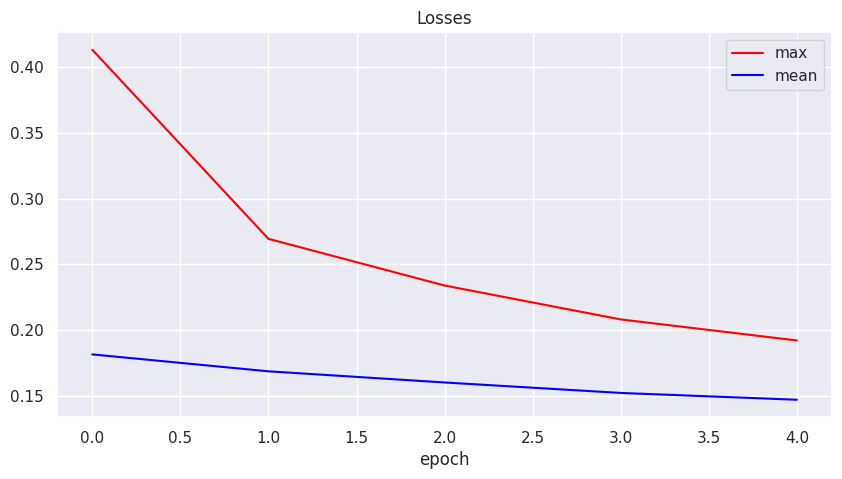

Лучшая accuracy для подхода max: 90.80
Лучшая accuracy для подхода mean: 91.00


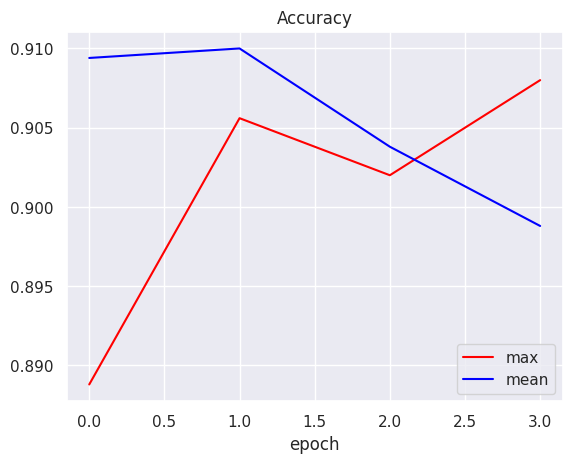

In [ ]:
losses_2rnn, acc_2rnn = train(model_2rnn, num_epoch=5)
plot_losses_accs(losses_2rnn, acc_2rnn)

Mean стартует выше, достигает пика в 0.910, но потом начинает монотонно снижаться.Похоже на переобучение.

Max начинает ниже, но затем растёт и выходит на 0.908.
Для двух слоев RNN max показывает себя лучше на долгой дистанции, а mean - хорошо только в начале.

Лоссы снижаются, mean меньше, но качество ни к черту.

###Три слоя RNN

In [ ]:
class RNN3LM(nn.Module):
    def __init__(
        self, hidden_dim: int, vocab_size: int, num_classes: int = 4,
        aggregation_type: str = 'max'
        ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.RNN(hidden_dim, hidden_dim, batch_first=True, num_layers=3)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

        self.aggregation_type = aggregation_type

    def forward(self, input_batch) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]

        if self.aggregation_type == 'max':
            output = output.max(dim=1)[0] #[batch_size, hidden_dim]
        elif self.aggregation_type == 'mean':
            output = output.mean(dim=1) #[batch_size, hidden_dim]
        else:
            raise ValueError("Invalid aggregation_type")

        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, hidden_dim]
        prediction = self.projection(self.non_lin(output))  # [batch_size, num_classes]

        return prediction

In [ ]:
model_3rnn = RNN3LM(hidden_dim=256, vocab_size=len(vocab)).to(device)

Starting training for max


Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/3750 [00:00<?, ?it/s]

...

Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/3750 [00:00<?, ?it/s]

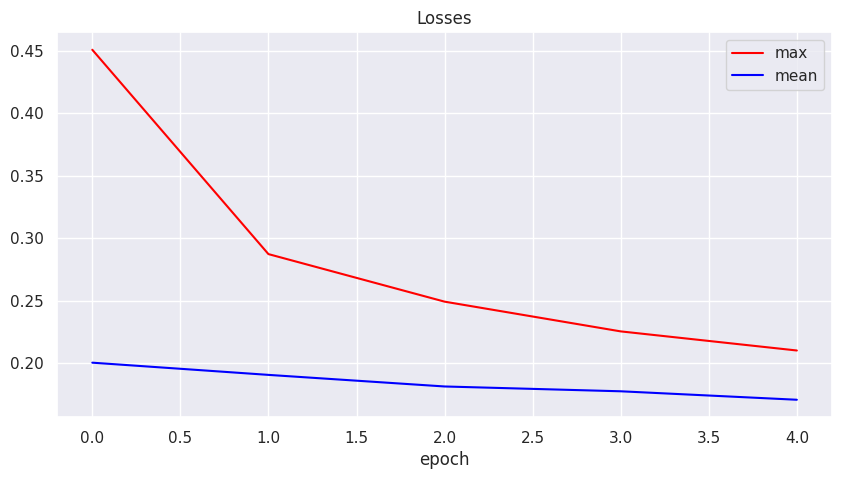

Лучшая accuracy для подхода max: 91.02
Лучшая accuracy для подхода mean: 90.86


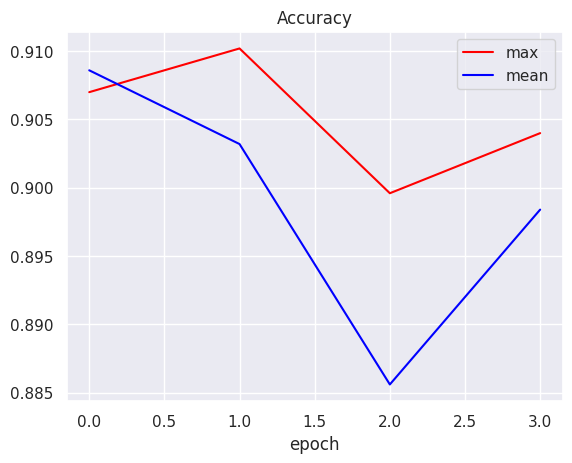

In [ ]:
losses_3rnn, acc_3rnn = train(model_3rnn, num_epoch=5)
plot_losses_accs(losses_3rnn, acc_3rnn)

Mean демонстрирует признаки нестабильности и переобучения, max лидирует: точность выше и колебания меньше.

Лоссы ведут себя идентично предыдущему случаю.

###Сравним результаты работы моделей с разным количеством RNN слоев

Лучшая accuracy для 2 RNN-слоя max: 90.80%
Лучшая accuracy для 3 RNN-слоя max: 91.02%
Лучшая accuracy для 1 RNN-слой max: 90.64%
Лучшая accuracy для 2 RNN-слоя mean: 91.00%
Лучшая accuracy для 3 RNN-слоя mean: 90.86%
Лучшая accuracy для 1 RNN-слой mean: 90.40%


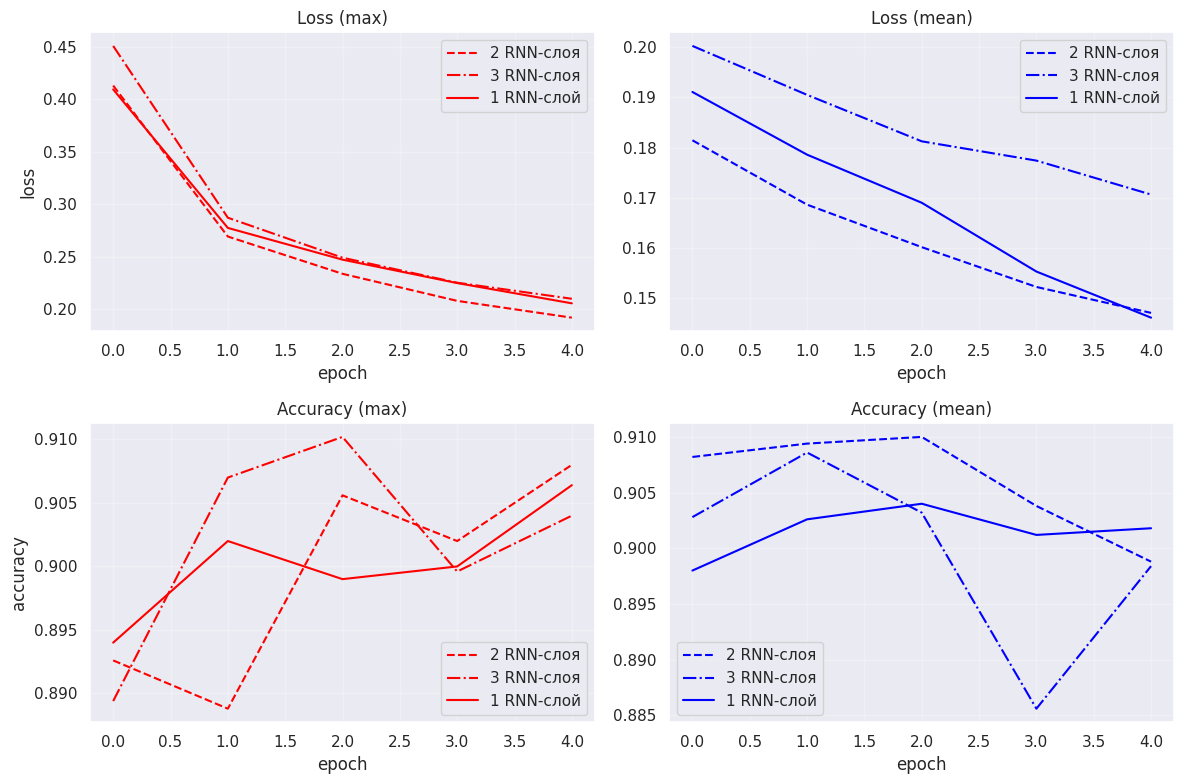

In [ ]:
plot_losses_accs_compare(
    losses_2rnn, acc_2rnn,
    losses_3rnn, acc_3rnn,
    losses_basic, acc_basic,
    basic_prefix="1 RNN-слой",
    type1_prefix="2 RNN-слоя",
    type2_prefix="3 RNN-слоя"
)

Схожие лоссы, но лосс 2 RNN наименьший. Для обоих видов агреггаций.

1 слой: и mean стабильнее, и max, но оба дают средние результаты.

2 слоя: оптимальный баланс - лучший loss и хороший accuracy (особенно max).

3 слоя: max держится лучше, чем mean (которая сыпется), но в целом стабильность падает.

Лучший выбор для RNN при максимизации accuracy: 2 слоя + max pooling.

## Изменение архитектуры после применения RNN слоя

Конкатенируем результат аггрегации и эмбеддинг с последнего токена

In [ ]:
import torch
import torch.nn as nn

class RNNConcatLM(nn.Module):
    def __init__(
        self, hidden_dim: int, vocab_size: int, num_classes: int = 4,
        aggregation_type: str = 'max', pad_idx: int = 0,
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.pad_idx = pad_idx
        self.aggregation_type = aggregation_type

        self.embedding  = nn.Embedding(vocab_size, hidden_dim, padding_idx=pad_idx)
        self.rnn        = nn.RNN(hidden_dim, hidden_dim, batch_first=True)
        self.linear     = nn.Linear(2 * hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, num_classes)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, input_ids) -> torch.Tensor:
        B, T = input_ids.shape
        device = input_ids.device

        emb = self.embedding(input_ids)
        rnn_out, _ = self.rnn(emb)
        mask = (input_ids != self.pad_idx).unsqueeze(-1)
        lengths = mask.squeeze(-1).sum(dim=1)

        if self.aggregation_type == 'max':
            rnn_masked = rnn_out.masked_fill(~mask, float('-inf'))
            agg = torch.amax(rnn_masked, dim=1)
            inf_rows = torch.isinf(agg).any(dim=1)
            if inf_rows.any():
                agg[inf_rows] = 0.0

        elif self.aggregation_type == 'mean':
            rnn_masked = rnn_out * mask
            sum_vec = rnn_masked.sum(dim=1)
            denom = lengths.clamp_min(1).unsqueeze(-1)
            agg = sum_vec / denom
            empty = (lengths == 0)
            if empty.any():
                agg[empty] = 0.0
        else:
            raise ValueError("Invalid aggregation_type: use 'max' or 'mean'")

        last_idx = (lengths - 1).clamp_min(0)                        # [B]
        batch_arange = torch.arange(B, device=device)
        last = rnn_out[batch_arange, last_idx, :]                    # [B, H]
        empty = (lengths == 0)
        if empty.any():
            last[empty] = 0.0
        feat = torch.cat([agg, last], dim=-1)                        # [B, 2H]
        h = self.dropout(self.non_lin(self.linear(feat)))            # [B, H]
        logits = self.projection(self.non_lin(h))                    # [B, num_classes]
        return logits


In [ ]:
model_concat = RNNConcatLM(hidden_dim=256, vocab_size=len(vocab), num_classes=4,
    aggregation_type='max', pad_idx=word2ind['<pad>']).to(device)

Starting training for max


Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/3750 [00:00<?, ?it/s]

...

Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/3750 [00:00<?, ?it/s]

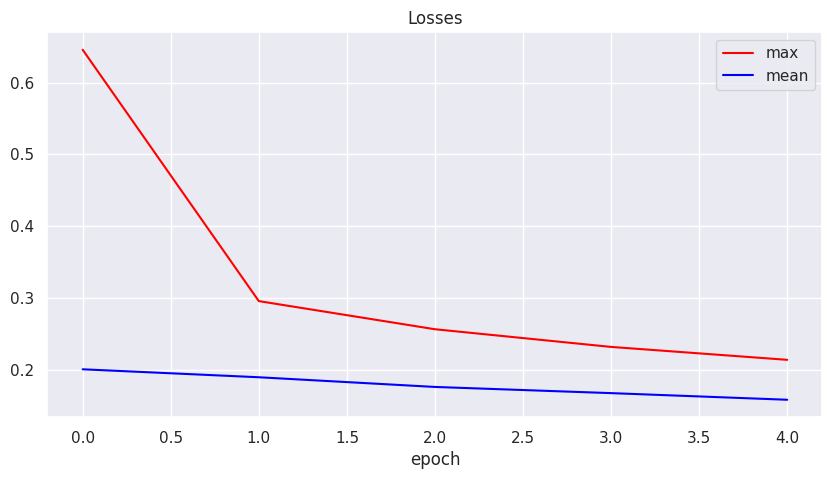

Лучшая accuracy для подхода max: 90.96
Лучшая accuracy для подхода mean: 90.54


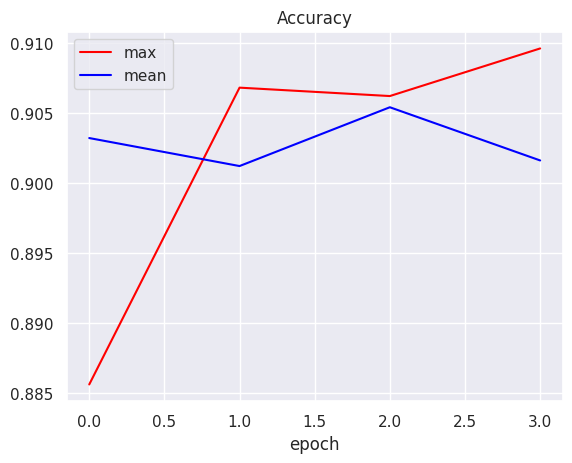

In [ ]:
losses_concat, acc_concat = train(model_concat, num_epoch=5)
plot_losses_accs(losses_concat, acc_concat)

Accuracy стабильней, чем когда-либо, особенно радует max. Mean по-прежнему даёт меньший loss, но max теперь не так отстает.

##Сравним результаты работы этой модели и базовой

Лучшая accuracy для Concatenation max: 90.96%
Лучшая accuracy для Baseline max: 90.64%
Лучшая accuracy для Concatenation mean: 90.54%
Лучшая accuracy для Baseline mean: 90.40%


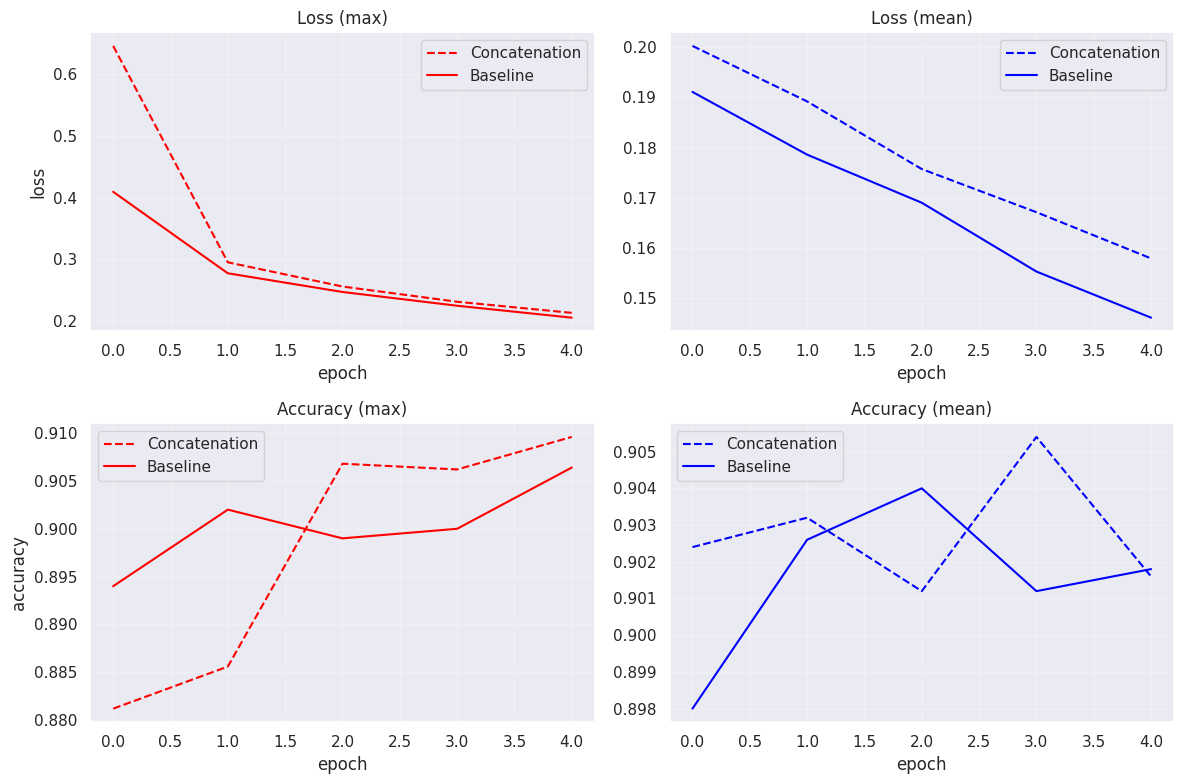

In [ ]:
plot_losses_accs_compare(
    losses_concat, acc_concat,
    None, None,
    losses_basic, acc_basic,
    basic_prefix="Baseline",
    type1_prefix='Concatenation'
)

Для Max конкатенация явно полезна - даёт лучший accuracy, хотя loss остаётся чуть-чуть выше.

Для Мean наблюдаем ухудшение loss, но пиковая accuracy на конкатенации превышает значение, полученное при базовой модели.

##Подбор размерности скрытого состояния

###Hidden_dim = 128

In [ ]:
model_128 = CharLM(hidden_dim=128, vocab_size=len(vocab)).to(device)

Starting training for max


Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/3750 [00:00<?, ?it/s]

...

Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/3750 [00:00<?, ?it/s]

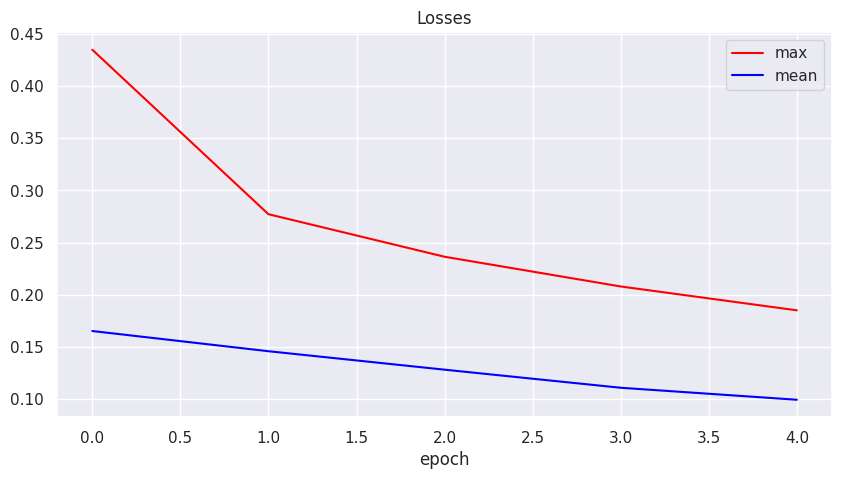

Лучшая accuracy для подхода max: 91.00
Лучшая accuracy для подхода mean: 90.52


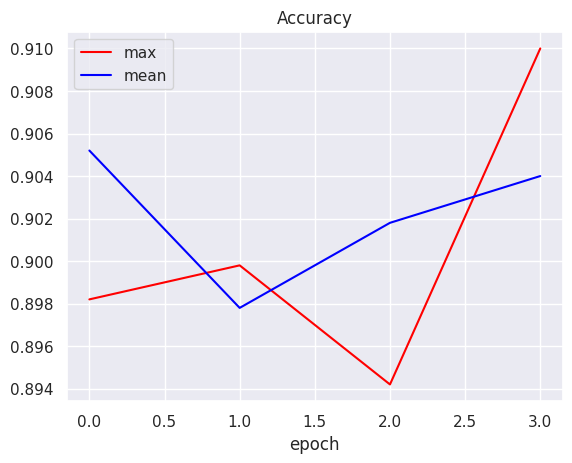

In [ ]:
losses_128, acc_128 = train(model_128, num_epoch=5)
plot_losses_accs(losses_128, acc_128)

При меньшем размере скрытого состояния accuracy у max летит вверх, а mean остаётся более стабильным, хоть и с чуть меньшим пиком.
Loss всё ещё сильно лучше у mean, но это не конвертируется напрямую в лучшую accuracy.

###Hidden_dim = 512

In [ ]:
model_512 = CharLM(hidden_dim=512, vocab_size=len(vocab)).to(device)

Starting training for max


Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/3750 [00:00<?, ?it/s]

...

Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/3750 [00:00<?, ?it/s]

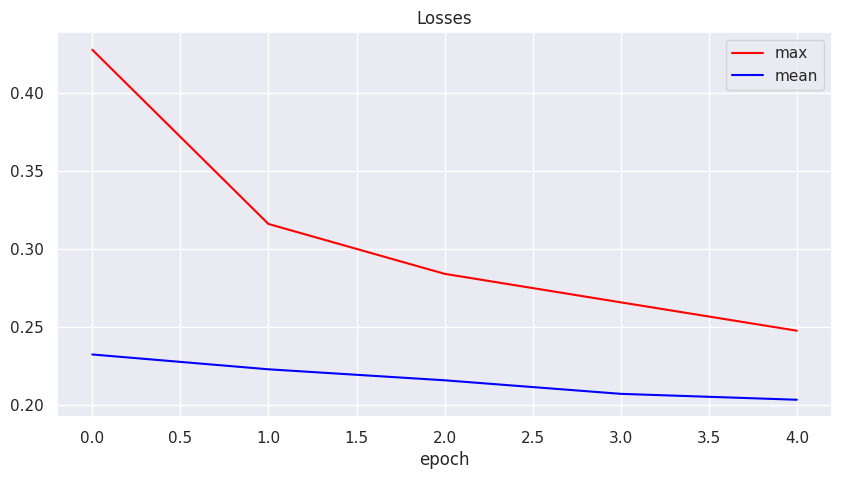

Лучшая accuracy для подхода max: 90.44
Лучшая accuracy для подхода mean: 90.76


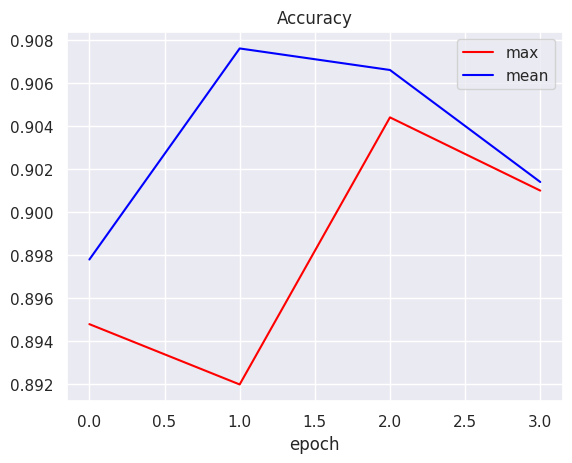

In [ ]:
losses_512, acc_512 = train(model_512, num_epoch=5)
plot_losses_accs(losses_512, acc_512)

При увеличении hidden_dim модель становится мощнее, и mean лидирует: стабильный низкий loss и более высокая accuracy.

Max при 512 уже не вытягивает точность выше mean.

### Посмотрим на графики моделей с hidden_dim = 128, 256, 512

Лучшая accuracy для 128 max: 91.00%
Лучшая accuracy для 512 max: 90.44%
Лучшая accuracy для 256 max: 90.64%
Лучшая accuracy для 128 mean: 90.52%
Лучшая accuracy для 512 mean: 90.76%
Лучшая accuracy для 256 mean: 90.40%


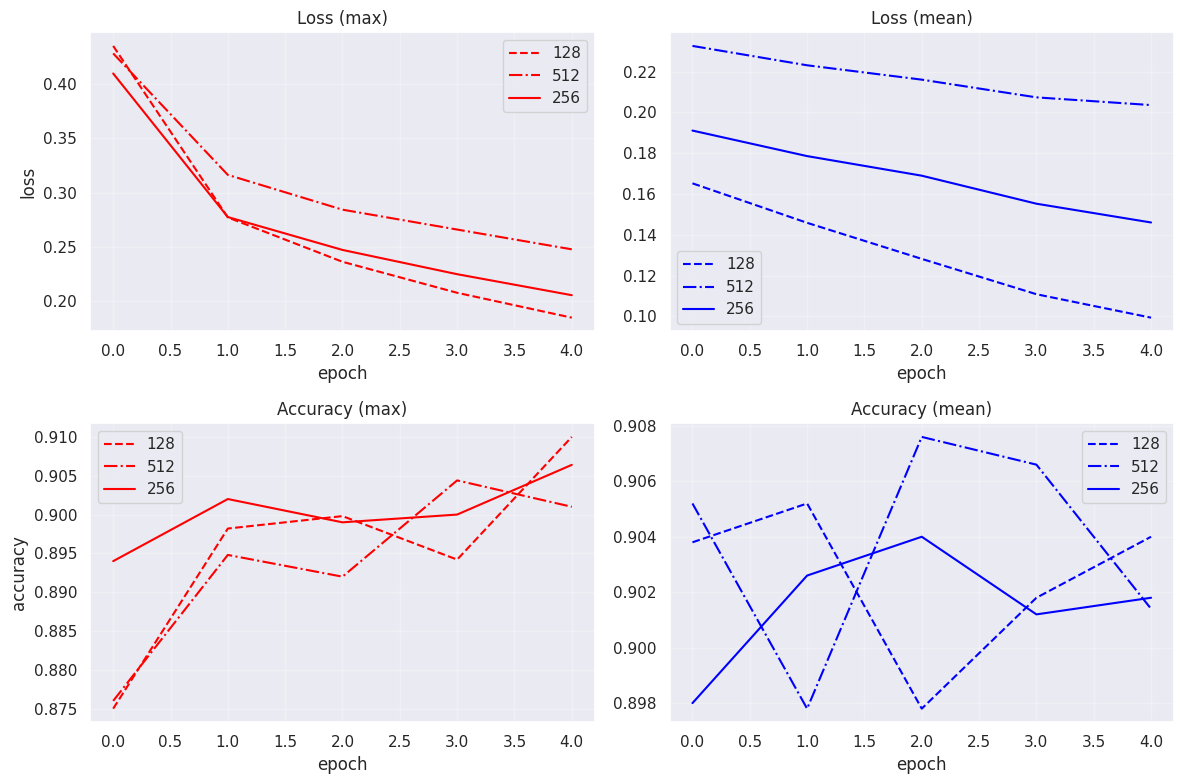

In [ ]:
plot_losses_accs_compare(
    losses_128, acc_128, losses_512, acc_512,
    losses_basic=losses_basic, acc_basic=acc_basic,
    type1_prefix="128", type2_prefix="512",
    basic_prefix="256"
)

Маленький hidden_dim явно лучше.

128 даёт лучшие пики и по loss (mean) и по accuracy (max). Лёгкая модель проще оптимизируется.

256 - золотая середина. Стабильная, хороший баланс между loss и accuracy.

512, несмотря на рекордный пик по accuracy для mean, хуже всех по loss и по стабильности. Модель слишком тяжёлая, начинает переобучаться.

##Увеличение количества эпох

In [ ]:
model_long = CharLM(hidden_dim=256, vocab_size=len(vocab)).to(device)

Starting training for max


Training epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/3750 [00:00<?, ?it/s]

...

Training epoch 5::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 6::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 7::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 8::   0%|          | 0/3750 [00:00<?, ?it/s]

Training epoch 9::   0%|          | 0/3750 [00:00<?, ?it/s]

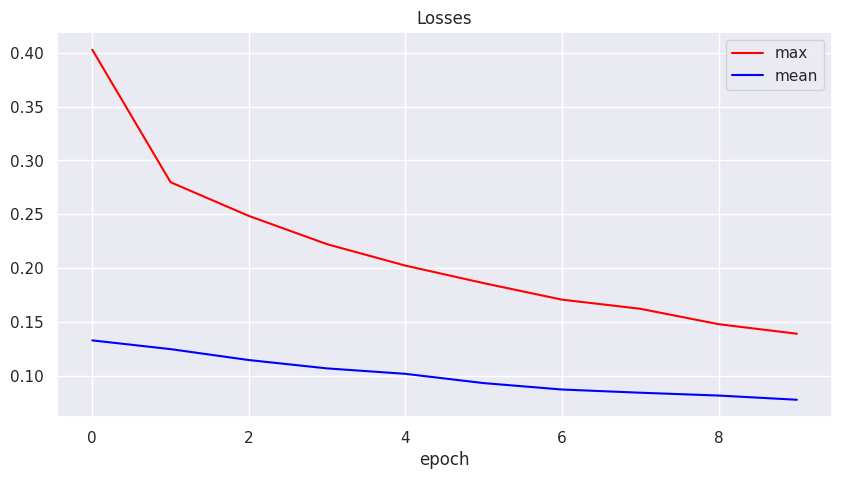

Лучшая accuracy для подхода max: 90.84
Лучшая accuracy для подхода mean: 90.24


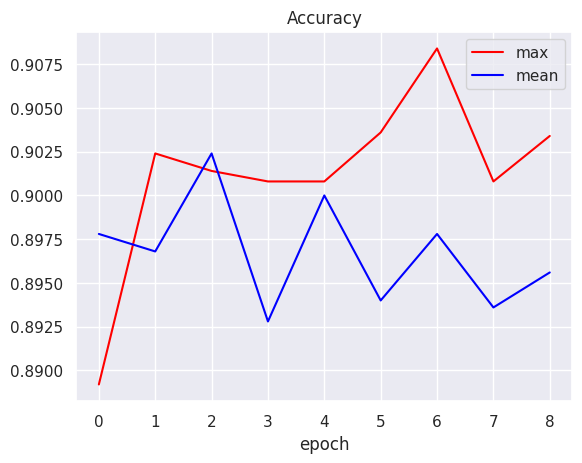

In [ ]:
losses_long, acc_long = train(model_long, num_epoch=10)
plot_losses_accs(losses_long, acc_long)

Лоссы продолжают убывать, accuracy на max достигает пика - обучение явно имеет смысл продлить дальше, чем на 5 эпох.

#Получение высокого качества

Возьмем модель, которая первой достигла наилучшего качества:

*   GRU
*   num_layers=1
*   hidden_dim = 256
*   aggregation_type - max

Ну и увеличим число эпох на всякий случай. И clip_grad_norm применим как профилактику дестабилизации.

In [ ]:
import torch, matplotlib.pyplot as plt
eval_steps = max(1, len(train_dataloader)//2)
num_epoch = 10
patience = 3
min_delta = 1e-4
losses = []
acc_steps = []
acc_epochs = []

model = GRULM(hidden_dim=256, vocab_size=len(vocab)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

best_acc = -1.0
best_path = "charlm_gru_max_best.pth"
last_path = "charlm_gru_max_last.pth"
epochs_no_improve = 0

for epoch in range(num_epoch):
    epoch_losses = []
    model.train()
    for i, batch in enumerate(tqdm(train_dataloader, desc=f'Training Epoch {epoch}:')):
        inputs = batch['input_ids'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_losses.append(loss.item())

        if (i + 1) % eval_steps == 0:
            acc_steps.append(evaluate(model, eval_dataloader))
            model.train()

    avg_loss = sum(epoch_losses) / max(1, len(epoch_losses))
    losses.append(avg_loss)

    epoch_acc = evaluate(model, eval_dataloader)
    acc_epochs.append(epoch_acc)

    print(f"[Epoch {epoch:02d}] train_loss={avg_loss:.4f} | val_acc={epoch_acc:.4f}")

    improved = epoch_acc > best_acc + min_delta
    if epoch_acc > 0.915 and improved:
        best_acc = epoch_acc
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_acc": epoch_acc,
            "config": {
                "hidden_dim": 256,
                "rnn_type": "gru",
                "num_layers": 1,
                "aggregation_type": "max",
                "vocab_size": len(vocab),
                "num_classes": 4,
            }
        }, best_path)
        print(f"New best! Saved checkpoint to {best_path} (val_acc={epoch_acc:.4f})")
        break

torch.save({
    "epoch": len(acc_epochs)-1,
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "val_acc": acc_epochs[-1] if acc_epochs else float('nan'),
}, last_path)
print(f"Last checkpoint saved to {last_path}")

Training Epoch 0::   0%|          | 0/3750 [00:00<?, ?it/s]

[Epoch 00] train_loss=0.3873 | val_acc=0.8984


Training Epoch 1::   0%|          | 0/3750 [00:00<?, ?it/s]

[Epoch 01] train_loss=0.2646 | val_acc=0.9116


Training Epoch 2::   0%|          | 0/3750 [00:00<?, ?it/s]

...

[Epoch 05] train_loss=0.1960 | val_acc=0.9118


Training Epoch 6::   0%|          | 0/3750 [00:00<?, ?it/s]

[Epoch 06] train_loss=0.1845 | val_acc=0.9138


Training Epoch 7::   0%|          | 0/3750 [00:00<?, ?it/s]

[Epoch 07] train_loss=0.1727 | val_acc=0.9176
New best! Saved checkpoint to charlm_gru_max_best.pth (val_acc=0.9176)
Last checkpoint saved to charlm_gru_max_last.pth


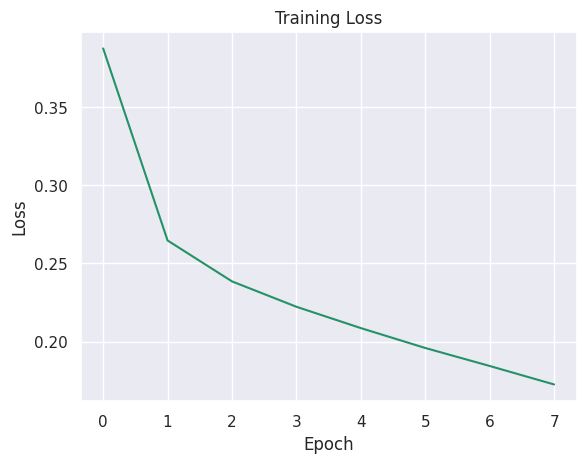

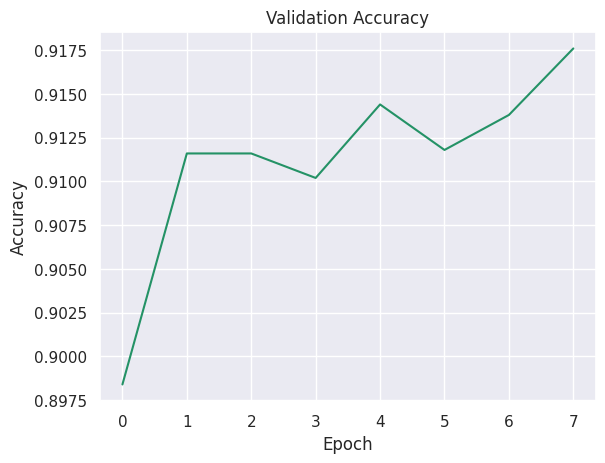

In [ ]:
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.plot(acc_epochs)
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

Есть!

In [ ]:
val_acc = evaluate(model, eval_dataloader)
print(f"Re-evaluated val_acc: {val_acc:.4f}")

Re-evaluated val_acc: 0.9176


#Выводы

В процессе обучения моделей были получены графики, к каждому из которых прилагаются комментарии выше по тексту.

А тут я размещу сводную таблицу:

In [ ]:
def summarize(name, losses_dict, acc_dict):
    rows = []
    for pooling in ['max', 'mean']:
        l = np.array(losses_dict[pooling], dtype=float)
        a = np.array(acc_dict[pooling], dtype=float)
        min_loss = float(l.min())
        min_loss_epoch = int(l.argmin())
        best_acc = float(a.max())
        best_acc_epoch = int(a.argmax())
        rows.append([name, pooling, min_loss,
                     best_acc, best_acc_epoch])
    return rows

rows = []
rows += summarize("RNN-1x256", losses_basic, acc_basic)
rows += summarize("GRU-1x256", losses_gru, acc_gru)
rows += summarize("LSTM-1x256", losses_lstm, acc_lstm)
rows += summarize("RNN-2x256", losses_2rnn, acc_2rnn)
rows += summarize("RNN-3x256", losses_3rnn, acc_3rnn)
rows += summarize("Concat(agg+last)-256", losses_concat, acc_concat)
rows += summarize("RNN-1x128", losses_128, acc_128)
rows += summarize("RNN-1x512", losses_512, acc_512)

cols = ["model", "pooling", "min_loss", "best_acc", "best_acc_epoch"]
df = pd.DataFrame(rows, columns=cols)

df_sorted = df.sort_values(by="best_acc", ascending=False).reset_index(drop=True)


In [ ]:
df_sorted

,model,pooling,min_loss,best_acc,best_acc_epoch
0,GRU-1x256,max,0.094939,0.9184,1
1,LSTM-1x256,max,0.072422,0.9152,1
2,GRU-1x256,mean,0.039043,0.9102,1
3,RNN-3x256,max,0.210058,0.9102,2
4,RNN-1x128,max,0.185049,0.9100,4
5,RNN-2x256,mean,0.146962,0.9100,2
6,Concat(agg+last)-256,max,0.213499,0.9096,4
7,LSTM-1x256,mean,0.031691,0.9088,1
8,RNN-3x256,mean,0.170609,0.9086,1
9,RNN-2x256,max,0.192058,0.9080,4


Подведем итоги:

RNN капризны, по крайней мере если гонять семинарскую модель на семинарском цикле.
Затухание и взрывы градиентов нарушают монотонность accuracy, которой мы так ждем, увеличивая количество эпох.
При обучении лучше пользоваться клиппингом и сохранять веса сразу, как появится желаемая метрика, иначе есть риск не взобраться на тут же вершину дважды.

**Если нужна стабильность и низкий loss:**

GRU или LSTM + mean, hidden_dim=256.
Это ровная и надёжная модель.

**Если нужна максимальная accuracy:**

GRU или LSTM + max (+ concat last token), hidden_dim=128–256.

**Если важна лёгкая модель:**

128 hidden + max (неплохой компромисс).

512 hidden_dim не нужен — даёт переобучение, больше ресурсов, хуже метрики.

Приём с конкатенацией last token усиливает max, стоит использовать.

С точки зрения эксперимента: mean = надёжность, max = пики качества.

Благодарю за прочтение 🙏 💙

Буду благодарна любой обратной связи :)